# Retrieval-Quality Judge (AI-judge comparison)

**Part of:** RAG chunking-strategy evaluation for the "AI Engineering" book chatbot project.

**What this notebook does:**
1. Loads the question bank generated by `01_Data_Preparation.ipynb`
2. Samples a random subset of questions
3. For each question, retrieves top-k chunks from all three Chroma collections
   (fixed-size, 3-sentence, single-sentence)
4. Asks a local LLM (via Ollama) to judge which set of retrieved chunks best
   supports answering the question — with method labels randomized per question
   to avoid positional bias
5. Aggregates win counts across the sample

**Depends on:** `chroma_db` (built by the three chunking notebooks) and
`questions_checkpoint.jsonl` (built by `01_Data_Preparation.ipynb`) both already
existing on disk.

## Imports

In [1]:
import json
import random
from pathlib import Path
from collections import Counter

import chromadb
import ollama
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

C:\Users\User\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and sample questions

Loads the full question bank, then takes a random sample. Fixed seed so the
sample is reproducible across reruns.

In [2]:
QUESTIONS_PATH = Path("questions_checkpoint.jsonl")

def load_questions(path: Path) -> list[dict]:
    all_questions = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            for q in row["questions"]:
                all_questions.append({"page": row["page"], **q})
    return all_questions

all_questions = load_questions(QUESTIONS_PATH)
print(f"Loaded {len(all_questions)} total questions")

sample_questions = all_questions  # judging the full bank now, not a sample
print(f"Judging {len(sample_questions)} questions")

Loaded 1145 total questions
Judging 1145 questions


## Connect to the three Chroma collections

Loads the same embedding model used to build the collections, so query
embeddings live in the same space.

In [7]:
CHROMA_PATH = "./Chunking/chroma_db"  # verify this path exists — see note above

chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

collections = {
    "fixed_size": chroma_client.get_collection("fixed_size_first5"),
    "three_sentence": chroma_client.get_collection("three_sentence_first5"),
    "single_sentence": chroma_client.get_collection("single_sentence_first5"),
}

for name, coll in collections.items():
    print(f"{name}: {coll.count()} chunks")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8c59eaf2-16f9-44f1-ac1d-fb788203d77b)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 76abb2ce-7c93-4fed-ba77-c90a1fd7046e)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/./modules.json
Retrying in 2s [Retry 2/5].


fixed_size: 1212 chunks
three_sentence: 1748 chunks
single_sentence: 4985 chunks


## Retrieval helper

Queries all three collections with the same embedded question and returns
their top-k retrieved passages.

In [8]:
def retrieve(question: str, top_k: int = 5) -> dict[str, list[str]]:
    query_embedding = embedding_model.encode([question]).tolist()
    results = {}
    for method, coll in collections.items():
        r = coll.query(query_embeddings=query_embedding, n_results=top_k)
        results[method] = r["documents"][0]
    return results

## Judge setup

Randomizes which method gets labeled A/B/C per question (avoids positional
bias), truncates each passage to 400 chars so the prompt stays a reasonable
size, and asks for strict JSON so the verdict is parseable.

In [16]:
JUDGE_MODEL = "llama3"

EVALUATION_GUIDELINE = """
You are evaluating RETRIEVAL quality for a RAG system — NOT answer quality.
You are not being shown a generated answer. You are being shown raw retrieved
passages, and judging whether they would let someone WRITE a good answer.

Score each set of passages on three criteria, 1-5 each, using these exact
definitions:

RELEVANCE — Do the passages relate to the question's topic at all?
   5 = Every passage is directly and clearly on-topic for the question.
   4 = Nearly all passages are on-topic; at most one minor drift.
   3 = About half the passages are on-topic; the rest are tangential.
   2 = Most passages are off-topic, with only a small on-topic fragment.
   1 = Passages are about a completely different topic than the question.

COVERAGE — Do the passages contain the actual fact/explanation needed to
   answer the question, not just something adjacent to it?
   5 = The specific information needed to fully answer the question is present.
   4 = Nearly the full answer is present, missing only a minor detail.
   3 = Passages are in the right neighborhood but only partially answer it,
       or require outside knowledge to connect the dots.
   2 = Passages gesture at the topic but don't contain the actual answer.
   1 = Nothing in the passages helps answer the question, even indirectly.

PRECISION — How much of the retrieved text is useful signal vs. noise
   (cut-off sentences, headers, table-of-contents fragments, boilerplate)?
   5 = Nearly all retrieved text is substantive and readable on its own.
   4 = Mostly clean, with one minor fragment or stray heading.
   3 = A mix — some passages are clean, others are fragments or noise.
   2 = Mostly fragments or noise, with one usable passage.
   1 = Mostly noise — fragments, headers, or text that doesn't stand alone.

Do NOT judge writing style, length, or which set "sounds" more complete —
score strictly against the definitions above.

Before assigning scores, briefly reason through each set against these
definitions. Do NOT include that reasoning in your output — only the final
JSON scores, nothing else.
"""

JUDGE_PROMPT = """{guideline}

Question: {question}

Set A:
{set_a}

Set B:
{set_b}

Set C:
{set_c}

For EACH set, give scores for relevance, coverage, and precision (1-5 each).
Respond with strict JSON, no other text:

{{
  "A": {{"relevance": <1-5>, "coverage": <1-5>, "precision": <1-5>}},
  "B": {{"relevance": <1-5>, "coverage": <1-5>, "precision": <1-5>}},
  "C": {{"relevance": <1-5>, "coverage": <1-5>, "precision": <1-5>}}
}}
"""

def format_set(chunks: list[str]) -> str:
    return "\n\n".join(f"[{i+1}] {c[:400]}" for i, c in enumerate(chunks))

def build_judge_prompt(question: str, retrieved: dict[str, list[str]]):
    methods = list(retrieved.keys())
    random.shuffle(methods)
    label_map = dict(zip(["A", "B", "C"], methods))

    prompt = JUDGE_PROMPT.format(
        guideline=EVALUATION_GUIDELINE,
        question=question,
        set_a=format_set(retrieved[label_map["A"]]),
        set_b=format_set(retrieved[label_map["B"]]),
        set_c=format_set(retrieved[label_map["C"]]),
    )
    return prompt, label_map

import re

def judge(prompt: str) -> dict:
    response = ollama.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": prompt}],
        format="json",
        options={"temperature": 0.0, "num_predict": 512},
    )
    raw = response["message"]["content"].strip()

    if raw.startswith("```"):
        raw = raw.strip("`")
        if raw.lower().startswith("json"):
            raw = raw[4:].strip()

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass

    return {"parse_error": raw}

### Sanity-check on one question 

In [17]:
test_q = sample_questions[0]
test_retrieved = retrieve(test_q["question"])
test_prompt, test_label_map = build_judge_prompt(test_q["question"], test_retrieved)

print(test_prompt)
print("\n--- label map ---")
print(test_label_map)

test_verdict = judge(test_prompt)
print("\n--- verdict ---")
print(test_verdict)


You are evaluating RETRIEVAL quality for a RAG system — NOT answer quality.
You are not being shown a generated answer. You are being shown raw retrieved
passages, and judging whether they would let someone WRITE a good answer.

Score each set of passages on three criteria, 1-5 each, using these exact
definitions:

RELEVANCE — Do the passages relate to the question's topic at all?
   5 = Every passage is directly and clearly on-topic for the question.
   4 = Nearly all passages are on-topic; at most one minor drift.
   3 = About half the passages are on-topic; the rest are tangential.
   2 = Most passages are off-topic, with only a small on-topic fragment.
   1 = Passages are about a completely different topic than the question.

COVERAGE — Do the passages contain the actual fact/explanation needed to
   answer the question, not just something adjacent to it?
   5 = The specific information needed to fully answer the question is present.
   4 = Nearly the full answer is present, missi

## Run the judge 

In [21]:
def total_score(scores: dict) -> int:
    return scores.get("relevance", 0) + scores.get("coverage", 0) + scores.get("precision", 0)

RESULTS_PATH = Path("judge_results_checkpoint.jsonl")
CHECKPOINT_EVERY = 20

# resume support: reload anything already judged, skip it this run
judge_results = []
already_done = set()
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            judge_results.append(row)
            already_done.add(row["question"])
    print(f"Resuming: {len(already_done)} questions already judged")

remaining = [q for q in sample_questions if q["question"] not in already_done]

with open(RESULTS_PATH, "a", encoding="utf-8") as f:
    for i, q in enumerate(tqdm(remaining, desc="Judging retrieval"), start=1):
        retrieved = retrieve(q["question"])
        prompt, label_map = build_judge_prompt(q["question"], retrieved)
        verdict = judge(prompt)

        if "parse_error" in verdict:
            result = {
                "question": q["question"], "page": q["page"],
                "label_map": label_map, "verdict": verdict, "parse_error": True,
            }
        else:
            scores_by_method = {label_map[label]: scores for label, scores in verdict.items()}
            winner_method = max(scores_by_method, key=lambda m: total_score(scores_by_method[m]))
            result = {
                "question": q["question"],
                "page": q["page"],
                "label_map": label_map,
                "scores_by_method": scores_by_method,
                "winner_method": winner_method,
                "parse_error": False,
            }

        judge_results.append(result)
        f.write(json.dumps(result) + "\n")

        if i % CHECKPOINT_EVERY == 0:
            f.flush()
            print(f"Checkpoint: {i}/{len(remaining)} this run ({len(judge_results)} total)")

print("Done.")

Resuming: 23 questions already judged


Judging retrieval:   2%|▏         | 20/1121 [01:35<1:26:47,  4.73s/it]

Checkpoint: 20/1121 this run (43 total)


Judging retrieval:   4%|▎         | 40/1121 [03:15<1:33:27,  5.19s/it]

Checkpoint: 40/1121 this run (63 total)


...

Checkpoint: 1100/1121 this run (1123 total)


Judging retrieval: 100%|█████████▉| 1120/1121 [1:31:39<00:04,  4.65s/it]

Checkpoint: 1120/1121 this run (1143 total)


Judging retrieval: 100%|██████████| 1121/1121 [1:31:44<00:00,  4.91s/it]

Done.


## Aggregate results

In [22]:
from collections import defaultdict

parse_errors = [r for r in judge_results if r.get("parse_error")]
valid_results = [r for r in judge_results if not r.get("parse_error")]
print(f"{len(parse_errors)} parse errors out of {len(judge_results)}")

wins = Counter(r["winner_method"] for r in valid_results)
print("\nWin counts:", dict(wins))

criterion_sums = defaultdict(lambda: defaultdict(list))
for r in valid_results:
    for method, scores in r["scores_by_method"].items():
        for criterion in ("relevance", "coverage", "precision"):
            criterion_sums[method][criterion].append(scores.get(criterion, 0))

print("\nAverage scores per method:")
for method, criteria in criterion_sums.items():
    avgs = {c: round(sum(v) / len(v), 2) for c, v in criteria.items()}
    print(f"  {method}: {avgs}")

0 parse errors out of 1144

Win counts: {'three_sentence': 366, 'fixed_size': 260, 'single_sentence': 518}

Average scores per method:
  single_sentence: {'relevance': 4.54, 'coverage': 3.76, 'precision': 3.64}
  three_sentence: {'relevance': 4.4, 'coverage': 3.61, 'precision': 3.39}
  fixed_size: {'relevance': 4.23, 'coverage': 3.43, 'precision': 3.24}


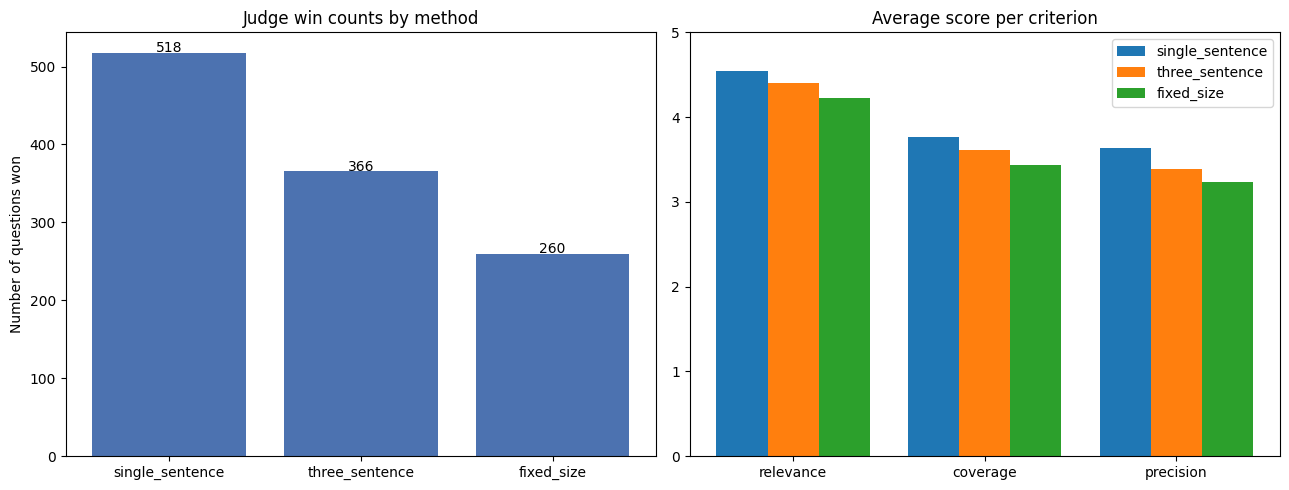

In [23]:
import matplotlib.pyplot as plt
import numpy as np

methods = list(criterion_sums.keys())
criteria = ("relevance", "coverage", "precision")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: win counts ---
win_counts = [wins.get(m, 0) for m in methods]
axes[0].bar(methods, win_counts, color="#4C72B0")
axes[0].set_title("Judge win counts by method")
axes[0].set_ylabel("Number of questions won")
for i, v in enumerate(win_counts):
    axes[0].text(i, v + 0.3, str(v), ha="center")

# --- Right: average score per criterion, grouped by method ---
x = np.arange(len(criteria))
width = 0.8 / len(methods)

for i, method in enumerate(methods):
    avgs = [
        sum(criterion_sums[method][c]) / len(criterion_sums[method][c])
        for c in criteria
    ]
    axes[1].bar(x + i * width, avgs, width, label=method)

axes[1].set_title("Average score per criterion")
axes[1].set_xticks(x + width * (len(methods) - 1) / 2)
axes[1].set_xticklabels(criteria)
axes[1].set_ylim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()